# Himawari-9 over Japan — HSD segments to RGBs and a cloud mask

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geotoolz/blob/main/docs/products/notebooks/himawari_japan.ipynb)

You build true colour and day cloud phase images of Japan from raw Himawari Standard Data, then add NOAA's L2 cloud mask on the same grid. The scene is the Japan area JP01 at 03:00 UTC on 8 October 2026, noon in Tokyo. Every file comes anonymously from NOAA's public `noaa-himawari9` bucket.

**What you'll learn:**

1. List and download HSD segments with `geoproducts.himawari.aws`, decompressed on the way in.
2. Read calibrated bands with `himawari.Reader`, whole or by a lon/lat window.
3. Read the NOAA cloud mask with `himawari.L2Reader`.
4. Put bands at 0.5, 1 and 2 km and the full-disk mask on one grid with `geoproducts.stack`.
5. Build true colour and day cloud phase, and mask clouds with `himawari.MaskClouds`.

The HSD format, calibration and the full preset table are on the [Himawari AHI page](../himawari.md).

## Setup

On Colab the next cell installs `geotoolz-products[himawari,operators]`; locally, use the workspace environment (`make install`).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "geotoolz @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz",
            "geotoolz-cloud @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz-cloud",
            "geotoolz-products[himawari,operators] @ git+https://github.com/jejjohnson/geotoolz@main#subdirectory=packages/geotoolz-products",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import tempfile
from datetime import datetime
from pathlib import Path

import geoproducts
import matplotlib.pyplot as plt
import numpy as np
from geoproducts import himawari
from geoproducts.himawari import aws
from georeader.geotensor import GeoTensor
from matplotlib.colors import BoundaryNorm, ListedColormap

import geotoolz as gz

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,matplotlib,h5py,georeader,geotoolz,geoproducts,geocloud",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.16
IPython version      : 9.13.0

numpy      : 2.4.5
matplotlib : 3.10.9
h5py       : 3.16.0
georeader  : unknown
geotoolz   : 0.9.0
geoproducts: 0.3.0
geocloud   : 0.3.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v80
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. Find the segments

`aws.list_segments` lists the HSD files of one 10-minute slot. The Japan area is scanned four times per slot (`JP01` … `JP04`), each one file per band; `area="JP01"` keeps the first.

In [4]:
SLOT: datetime = datetime(2026, 10, 8, 3, 0)  # naive → UTC · 12:00 in Tokyo

segments: list[aws.Segment] = aws.list_segments(start=SLOT, sector="Japan", area="JP01")
for seg in segments[:6]:
    print(f"{seg.band}  {seg.size / 1e6:5.2f} MB  {seg.name}")
print(f"… {len(segments)} bands in all")

B01   3.38 MB  HS_H09_20261008_0300_B01_JP01_R10_S0101.DAT.bz2
B02   3.38 MB  HS_H09_20261008_0300_B02_JP01_R10_S0101.DAT.bz2
B03  13.22 MB  HS_H09_20261008_0300_B03_JP01_R05_S0101.DAT.bz2
B04   3.82 MB  HS_H09_20261008_0300_B04_JP01_R10_S0101.DAT.bz2
B05   0.90 MB  HS_H09_20261008_0300_B05_JP01_R20_S0101.DAT.bz2
B06   0.87 MB  HS_H09_20261008_0300_B06_JP01_R20_S0101.DAT.bz2
… 16 bands in all


Six bands cover both recipes and the cloud mask's display: B01–B04 for true colour, B05 and B13 for day cloud phase. `decompress=True` stores each segment as plain `.DAT`, which the reader memory-maps. Downloads go to a temporary directory.

In [5]:
BANDS: tuple[str, ...] = ("B01", "B02", "B03", "B04", "B05", "B13")
DATA: Path = Path(tempfile.mkdtemp(prefix="himawari-"))

paths: dict[str, Path] = {
    seg.band: aws.download(seg, DATA, decompress=True)
    for seg in segments
    if seg.band in BANDS
}
for band, path in paths.items():
    print(f"{band}  {path.stat().st_size / 1e6:6.1f} MB  {path.name}")

B01    14.4 MB  HS_H09_20261008_0300_B01_JP01_R10_S0101.DAT
B02    14.4 MB  HS_H09_20261008_0300_B02_JP01_R10_S0101.DAT
B03    57.6 MB  HS_H09_20261008_0300_B03_JP01_R05_S0101.DAT
B04    14.4 MB  HS_H09_20261008_0300_B04_JP01_R10_S0101.DAT
B05     3.6 MB  HS_H09_20261008_0300_B05_JP01_R20_S0101.DAT
B13     3.6 MB  HS_H09_20261008_0300_B13_JP01_R20_S0101.DAT


## 2. Read calibrated bands

`himawari.Reader` decodes an HSD segment onto its `+proj=geos` grid. `calibration=` picks the output: reflectance for B01–B06, brightness temperature for B07–B16. The coefficients come from the file's own header.

In [6]:
red: himawari.Reader = himawari.Reader(paths["B03"], calibration="reflectance")
bt13: himawari.Reader = himawari.Reader(
    paths["B13"], calibration="brightness_temperature"
)

for r in (red, bt13):
    print(
        f"{r.band} {r.wavelength_um:5.2f} µm  {r.shape}  {r.transform.a:.0f} m  {r.units}"
    )
print(f"B03 updated visible gain: {red.header.updated_gain}")

B03  0.64 µm  (1, 4800, 6000)  500 m  1
B13 10.41 µm  (1, 1200, 1500)  2000 m  K
B03 updated visible gain: 0.30901666


The reader is lazy. `read_from_bounds` decodes only the pixels under a lon/lat box, here Tokyo Bay at B03's native 0.5 km.

(1, 162, 214) float32


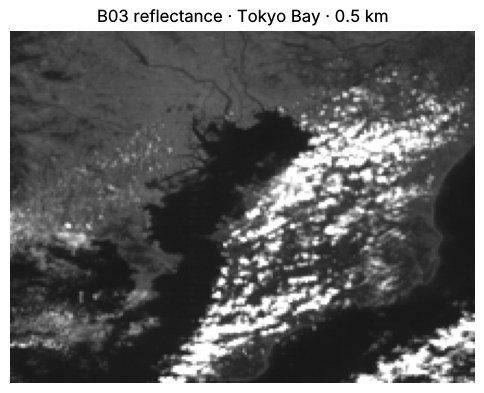

In [7]:
TOKYO: tuple[float, float, float, float] = (139.3, 34.9, 140.5, 35.9)  # lon/lat box
bay: GeoTensor = red.read_from_bounds(
    TOKYO, crs_bounds="EPSG:4326"
)  # (1, h, w) float32
print(bay.shape, bay.dtype)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.asarray(bay)[0], cmap="gray", vmin=0, vmax=0.4)
ax.set_title("B03 reflectance · Tokyo Bay · 0.5 km")
ax.set_axis_off()
plt.show()

## 3. Read the NOAA cloud mask

NOAA runs its cloud algorithms on every full-disk scan and publishes the results as NetCDF-4. `himawari.L2Reader` places the mask on the 2 km full-disk grid. The file is about 370 MB, the largest download here.

In [8]:
(cmsk,) = aws.list_l2(start=SLOT)  # product="CMSK", the cloud mask
print(f"{cmsk.size / 1e6:.0f} MB  {cmsk.name}")

mask: himawari.L2Reader = himawari.L2Reader(aws.download(cmsk, DATA))
print(mask.bands, mask.shape, mask.dtype)
print(mask.flags("CloudMask"))

368 MB  AHI-CMSK_v1r1_h09_s202610080300213_e202610080309407_c202610080314124.nc


('CloudMaskBinary', 'CloudMask') (2, 5500, 5500) int8
{0: 'clear', 1: 'probably_clear', 2: 'probably_cloudy', 3: 'cloudy'}


## 4. Put everything on one grid

`geoproducts.stack` uses the first reader's grid, here B13's 2 km Japan area. Finer bands are averaged down, and the full-disk mask is cut to the area and resampled with `mode`.

In [9]:
readers: list[himawari.Reader | himawari.L2Reader] = [
    bt13,  # reference: the 2 km grid
    *(himawari.Reader(paths[b], calibration="reflectance") for b in BANDS[:5]),
    mask,  # full disk → cut to the Japan area
]
scene: GeoTensor = geoproducts.stack(readers)  # 8 readers → (8, 1200, 1500) float32
print(scene.shape, scene.dtype)
print(scene.attrs["band_names"])

(8, 1200, 1500) float32
('B13', 'B01', 'B02', 'B03', 'B04', 'B05', 'CloudMaskBinary', 'CloudMask')


## 5. RGB recipes and the cloud mask

`himawari.TrueColor()` mixes a hybrid green from B02 and B04, because B02 alone makes vegetation too dark. `himawari.DayCloudPhase()` shows ice tops red and liquid low cloud cyan. `himawari.MaskClouds()` reads `CloudMaskBinary` and returns `True` for cloud.

In [10]:
# Shapes: C = 8 bands, H × W = 1200 × 1500 pixels.
true_color: GeoTensor = himawari.TrueColor()(scene)  #    (C, H, W) → (3, H, W) float32
cloud_phase: GeoTensor = himawari.DayCloudPhase()(
    scene
)  #                                                (C, H, W) → (3, H, W) float32
cloudy: GeoTensor = himawari.MaskClouds()(scene)  # (C, H, W) → (H, W) bool

print(f"cloudy: {np.mean(cloudy):.1%} of the area")

cloudy: 35.1% of the area


The figures plot every second pixel of the 1200 × 1500 grid. The black corners lie outside the JP01 scan, so the bands are `NaN` there; the cloud mask, cut from the full disk, still covers them.

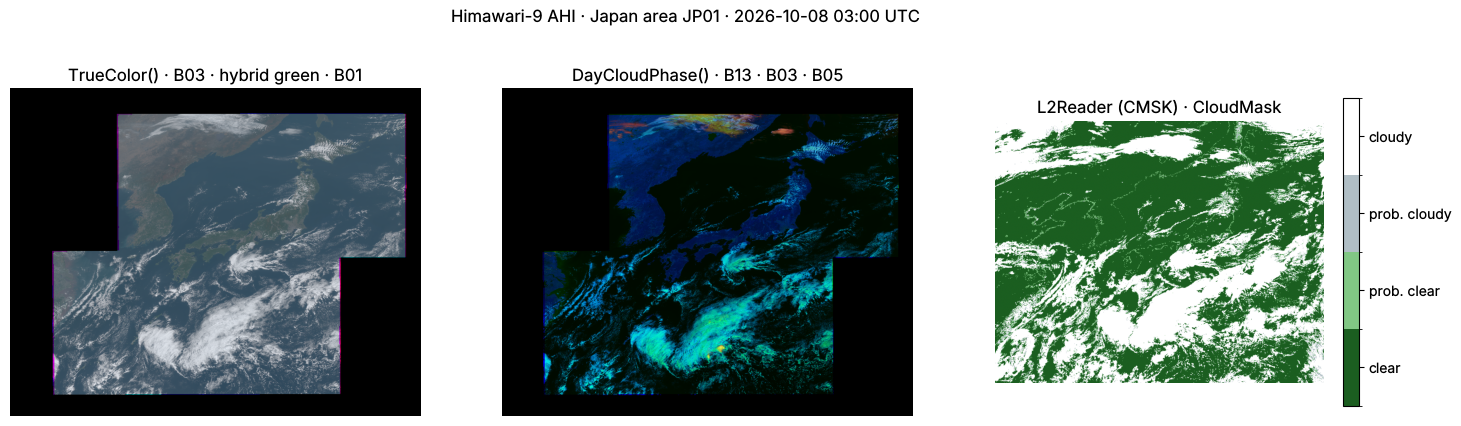

In [11]:
STEP: int = 2  # plot every second pixel


def rgb_image(rgb: GeoTensor) -> np.ndarray:
    """A decimated (h, w, 3) image of a (3, H, W) RGB, NaN as black."""
    image: np.ndarray = np.moveaxis(np.asarray(rgb), 0, -1)  # (3, H, W) → (H, W, 3)
    return np.nan_to_num(image[::STEP, ::STEP])  #             (H, W, 3) → (h, w, 3)


classes: np.ndarray = np.asarray(gz.spectral.SelectBands(bands=["CloudMask"])(scene))[
    0, ::STEP, ::STEP
]  # (C, H, W) → (h, w) float32 · 0-3, NaN = off the disk
cmap: ListedColormap = ListedColormap(["#1b5e20", "#81c784", "#b0bec5", "#ffffff"])
norm: BoundaryNorm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_image(true_color))
axes[0].set_title("TrueColor() · B03 · hybrid green · B01")
axes[1].imshow(rgb_image(cloud_phase))
axes[1].set_title("DayCloudPhase() · B13 · B03 · B05")
im = axes[2].imshow(classes, cmap=cmap, norm=norm)
axes[2].set_title("L2Reader (CMSK) · CloudMask")
bar = fig.colorbar(im, ax=axes[2], ticks=[0, 1, 2, 3], shrink=0.8)
bar.ax.set_yticklabels(["clear", "prob. clear", "prob. cloudy", "cloudy"])
for ax in axes:
    ax.set_axis_off()
fig.suptitle(f"Himawari-9 AHI · Japan area JP01 · {SLOT:%Y-%m-%d %H:%M} UTC")
plt.show()

### Clear-sky true colour

`gz.mask.ApplyMask` with `himawari.MaskClouds()` blanks the cloudy pixels. Apply it to the bands the recipe reads plus the mask band, then take the true colour. A `Sequential` chains the three steps:

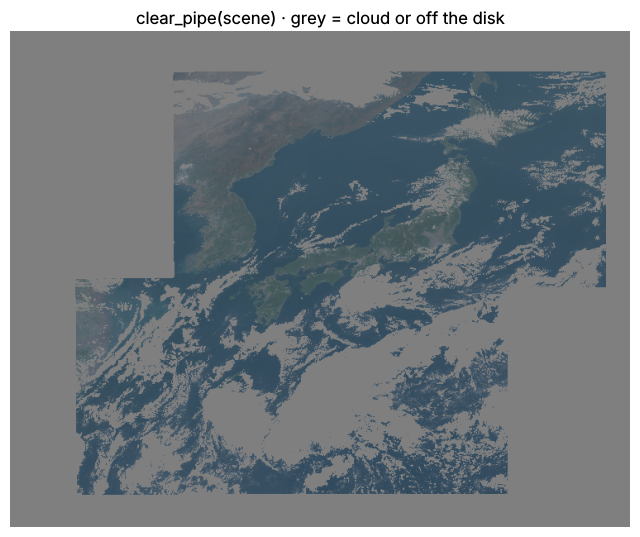

In [12]:
keep: gz.spectral.SelectBands = gz.spectral.SelectBands(
    bands=["B01", "B02", "B03", "B04", "CloudMaskBinary"]
)
clear_pipe: gz.Sequential = (
    keep | gz.mask.ApplyMask(mask=himawari.MaskClouds()) | himawari.TrueColor()
)
clear_rgb: GeoTensor = clear_pipe(scene)  # (C, H, W) → (3, H, W) float32 · cloud = NaN

image: np.ndarray = np.moveaxis(np.asarray(clear_rgb), 0, -1)[
    ::STEP, ::STEP
]  # (h, w, 3)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.imshow(np.nan_to_num(image, nan=0.5))
ax.set_title("clear_pipe(scene) · grey = cloud or off the disk")
ax.set_axis_off()
plt.show()

## Summary

- `himawari.aws.list_segments` and `download(decompress=True)` fetch HSD segments from NOAA's anonymous bucket, ready to memory-map.
- `himawari.Reader` calibrates each band from its own header and reads windows lazily.
- `himawari.L2Reader` puts NOAA's full-disk cloud mask on the AHI grid, and `geoproducts.stack` cuts it to any area.
- The presets (`TrueColor`, `DayCloudPhase`, `MaskClouds`) are the GOES ones bound to AHI band names.

Next: the GOES-19 version with parallax correction in [GOES-19 mesoscale](goes_mesoscale.ipynb), and the reader reference on the [Himawari AHI page](../himawari.md).